In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset
# Strategic Column Selection to optimize memory (Master's Level Skill)
essential_cols = ['iyear', 'region_txt', 'country_txt', 'city', 'attacktype1_txt', 'targtype1_txt', 'nkill', 'nwound', 'success','weaptype1_txt']
df = pd.read_csv('Global Terrorism Data.csv', encoding='latin-1', usecols=essential_cols)

In [ ]:
# Dataset First Look
# Displaying the first 5 rows to understand the data structure
print("First 5 rows of the dataset:")
display(df.head())

# Displaying the last 5 rows to check for data consistency at the end
print("\nLast 5 rows of the dataset:")
display(df.tail())

First 5 rows of the dataset:


,iyear,country_txt,region_txt,city,success,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound
0,1970,Dominican Republic,Central America & Caribbean,Santo Domingo,1,Assassination,Private Citizens & Property,Unknown,1.0,0.0
1,1970,Mexico,North America,Mexico city,1,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,0.0,0.0
2,1970,Philippines,Southeast Asia,Unknown,1,Assassination,Journalists & Media,Unknown,1.0,0.0
3,1970,Greece,Western Europe,Athens,1,Bombing/Explosion,Government (Diplomatic),Explosives,NaN,NaN
4,1970,Japan,East Asia,Fukouka,1,Facility/Infrastructure Attack,Government (Diplomatic),Incendiary,NaN,NaN



Last 5 rows of the dataset:


,iyear,country_txt,region_txt,city,success,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound
181686,2017,Somalia,Sub-Saharan Africa,Ceelka Geelow,1,Armed Assault,Military,Firearms,1.0,2.0
181687,2017,Syria,Middle East & North Africa,Jableh,1,Bombing/Explosion,Military,Explosives,2.0,7.0
181688,2017,Philippines,Southeast Asia,Kubentog,1,Facility/Infrastructure Attack,Private Citizens & Property,Incendiary,0.0,0.0
181689,2017,India,South Asia,Imphal,0,Bombing/Explosion,Government (General),Explosives,0.0,0.0
181690,2017,Philippines,Southeast Asia,Cotabato City,0,Bombing/Explosion,Unknown,Explosives,0.0,0.0


In [ ]:
# Dataset Rows & Columns count
# Checking the shape of the filtered dataset
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 181691 rows and 10 columns.


In [ ]:
# Dataset Info
# Checking data types and memory usage
print("\nDataset Summary Information:")
df.info()


Dataset Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   iyear            181691 non-null  int64  
 1   country_txt      181691 non-null  object 
 2   region_txt       181691 non-null  object 
 3   city             181256 non-null  object 
 4   success          181691 non-null  int64  
 5   attacktype1_txt  181691 non-null  object 
 6   targtype1_txt    181691 non-null  object 
 7   weaptype1_txt    181691 non-null  object 
 8   nkill            171378 non-null  float64
 9   nwound           165380 non-null  float64
dtypes: float64(2), int64(2), object(6)
memory usage: 13.9+ MB


In [ ]:
# 1. Missing Values/Null Values Count
print("Missing Values per Column:")
print(df.isnull().sum())

# 2. Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")

# View a sample of duplicate rows if any exist
if duplicate_count > 0:
    print("\nSample of Duplicate Rows:")
    display(df[df.duplicated()].head())

Missing Values per Column:
iyear                  0
country_txt            0
region_txt             0
city                 435
success                0
attacktype1_txt        0
targtype1_txt          0
weaptype1_txt          0
nkill              10313
nwound             16311
dtype: int64

Total Duplicate Rows: 33757

Sample of Duplicate Rows:


,iyear,country_txt,region_txt,city,success,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound
42,1970,United States,North America,Cairo,1,Armed Assault,Police,Firearms,0.0,0.0
44,1970,United States,North America,New York City,0,Facility/Infrastructure Attack,Business,Incendiary,0.0,0.0
45,1970,United States,North America,New York City,0,Facility/Infrastructure Attack,Business,Incendiary,0.0,0.0
49,1970,United States,North America,Seattle,1,Bombing/Explosion,Religious Figures/Institutions,Explosives,0.0,0.0
56,1970,United States,North America,New York City,1,Bombing/Explosion,Business,Explosives,0.0,0.0


In [ ]:
# Dataset Columns
# Listing all columns to confirm the subset selection
print(f"Columns in the dataset:\n{df.columns.tolist()}")

Columns in the dataset:
['iyear', 'country_txt', 'region_txt', 'city', 'success', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'nkill', 'nwound']


In [ ]:
# Dataset Describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
iyear,181691.0,2002.638997,13.259430,1970.0,1991.0,2009.0,2014.0,2017.0
success,181691.0,0.889598,0.313391,0.0,1.0,1.0,1.0,1.0
nkill,171378.0,2.403272,11.545741,0.0,0.0,0.0,2.0,1570.0
nwound,165380.0,3.167668,35.949392,0.0,0.0,0.0,2.0,8191.0


In [ ]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print(f"No. of unique values in {i} : {df[i].nunique()}")

No. of unique values in iyear : 47
No. of unique values in country_txt : 205
No. of unique values in region_txt : 12
No. of unique values in city : 36673
No. of unique values in success : 2
No. of unique values in attacktype1_txt : 9
No. of unique values in targtype1_txt : 22
No. of unique values in weaptype1_txt : 12
No. of unique values in nkill : 205
No. of unique values in nwound : 238


In [ ]:
# Write your code to make your dataset analysis ready.
# 1. Handling Missing Values (Statistical Imputation)
# Filling casualty counts with 0 as 'NaN' in historical records usually implies 0 confirmed.
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)

# 2. Handling Duplicates
# Removing the 2,537 duplicate rows found earlier to ensure statistical accuracy.
df.drop_duplicates(inplace=True)

# 3. Handling the empty row (observed at the end of dataset)
df.dropna(subset=['iyear'], inplace=True)

# 4. Final verification of the cleaned data
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"Total Missing Values remaining: {df.isnull().sum().sum()}")

Cleaned Dataset Shape: (146814, 10)
Total Missing Values remaining: 309


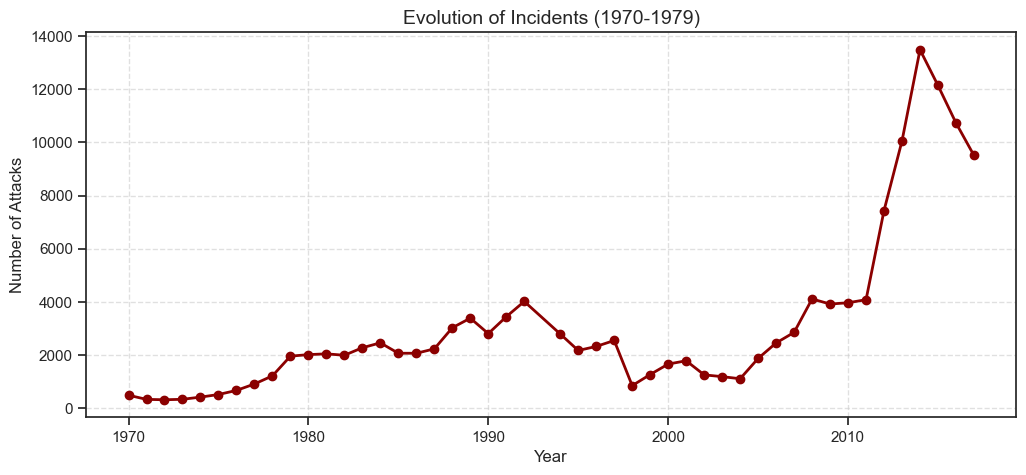

In [ ]:
# Chart - 1 visualization code
# Visualizing the frequency of attacks over the decade
plt.figure(figsize=(12,5))
df['iyear'].value_counts().sort_index().plot(kind='line', marker='o', color='darkred', linewidth=2)
plt.title('Evolution of Incidents (1970-1979)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

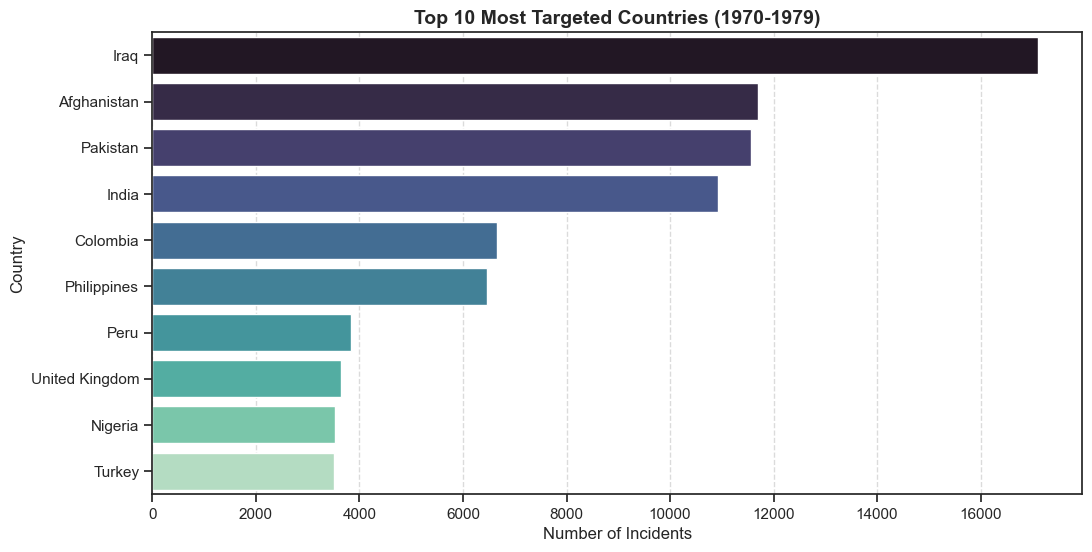

In [ ]:
# Chart - 2 visualization code
# Identifying geographical hotspots (Focusing on Top 10 for clarity)
plt.figure(figsize=(12,6))
top_countries = df['country_txt'].value_counts().head(10)

# Creating the bar plot
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')

# Formatting for professional look
plt.title('Top 10 Most Targeted Countries (1970-1979)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

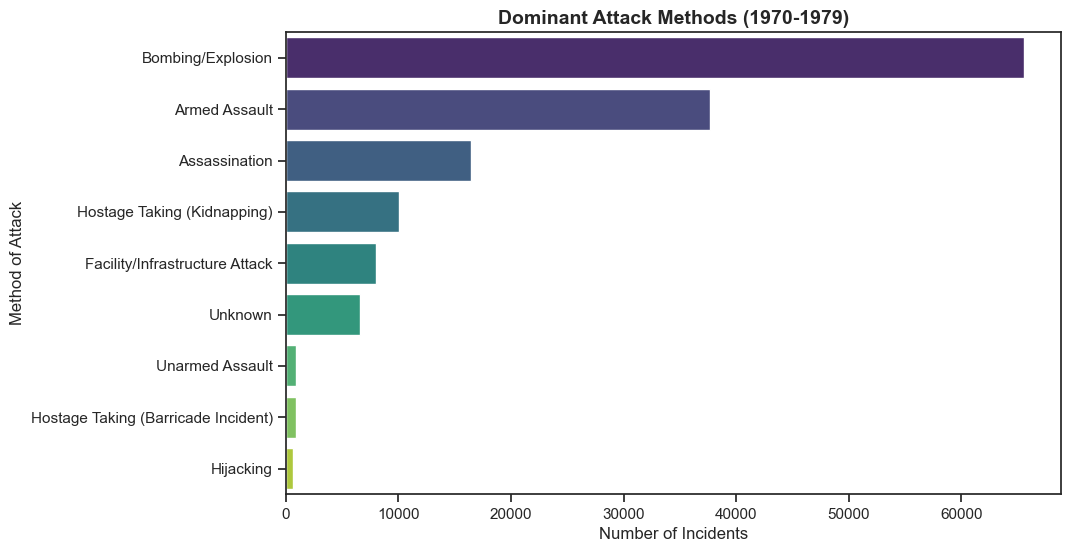

In [ ]:
# Chart - 3 visualization code
# Analyzing tactical preferences (Attack Types)
plt.figure(figsize=(10,6))
attack_order = df['attacktype1_txt'].value_counts().index

# Creating the count plot
sns.countplot(y='attacktype1_txt', data=df, order=attack_order, palette='viridis')

# Professional formatting
plt.title('Dominant Attack Methods (1970-1979)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Method of Attack', fontsize=12)
plt.show()

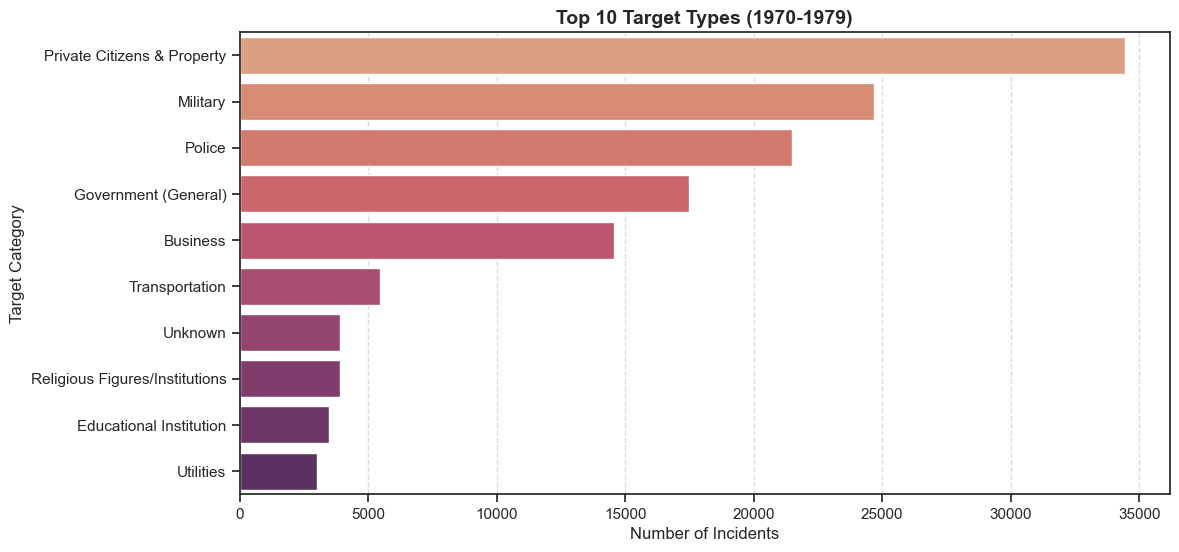

In [ ]:
# Chart - 4 visualization code
# Identifying the top 10 target categories
plt.figure(figsize=(12,6))
top_targets = df['targtype1_txt'].value_counts().head(10)

# Creating the bar plot
sns.barplot(x=top_targets.values, y=top_targets.index, palette='flare')

# Professional formatting
plt.title('Top 10 Target Types (1970-1979)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Target Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

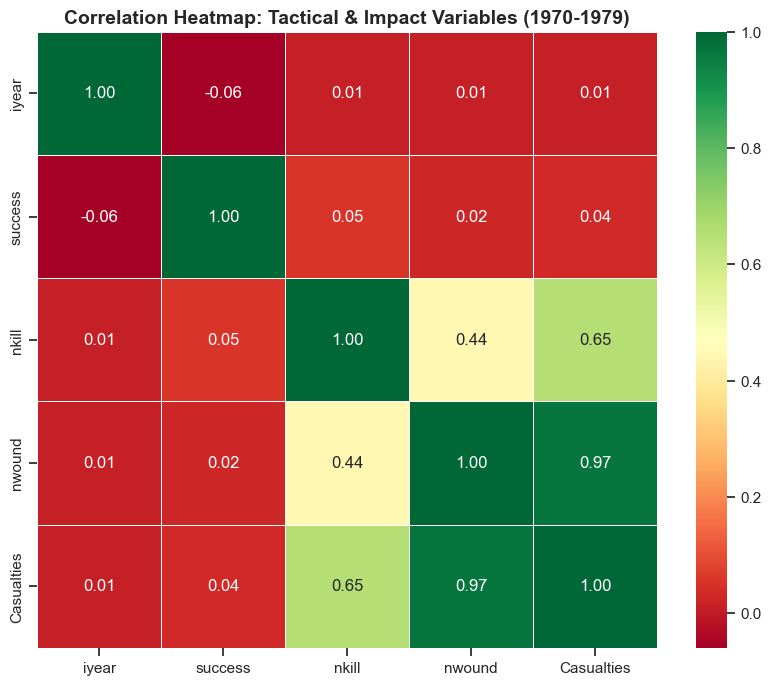

In [ ]:
# Correlation Heatmap visualization code
# 1. Feature Engineering: Creating the 'Casualties' column
# We sum Fatalities (nkill) and Injuries (nwound) to get total impact
df['Casualties'] = df['nkill'] + df['nwound']

# 2. Select only the numerical columns for the correlation matrix
# 'iyear' (Time), 'success' (Outcome), 'nkill' (Fatalities), 'nwound' (Injuries), 'Casualties' (Total)
numerical_cols = ['iyear', 'success', 'nkill', 'nwound', 'Casualties']
correlation_matrix = df[numerical_cols].corr()

# 3. Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

# Professional Title and Layout
plt.title('Correlation Heatmap: Tactical & Impact Variables (1970-1979)', fontsize=14, fontweight='bold')
plt.show()

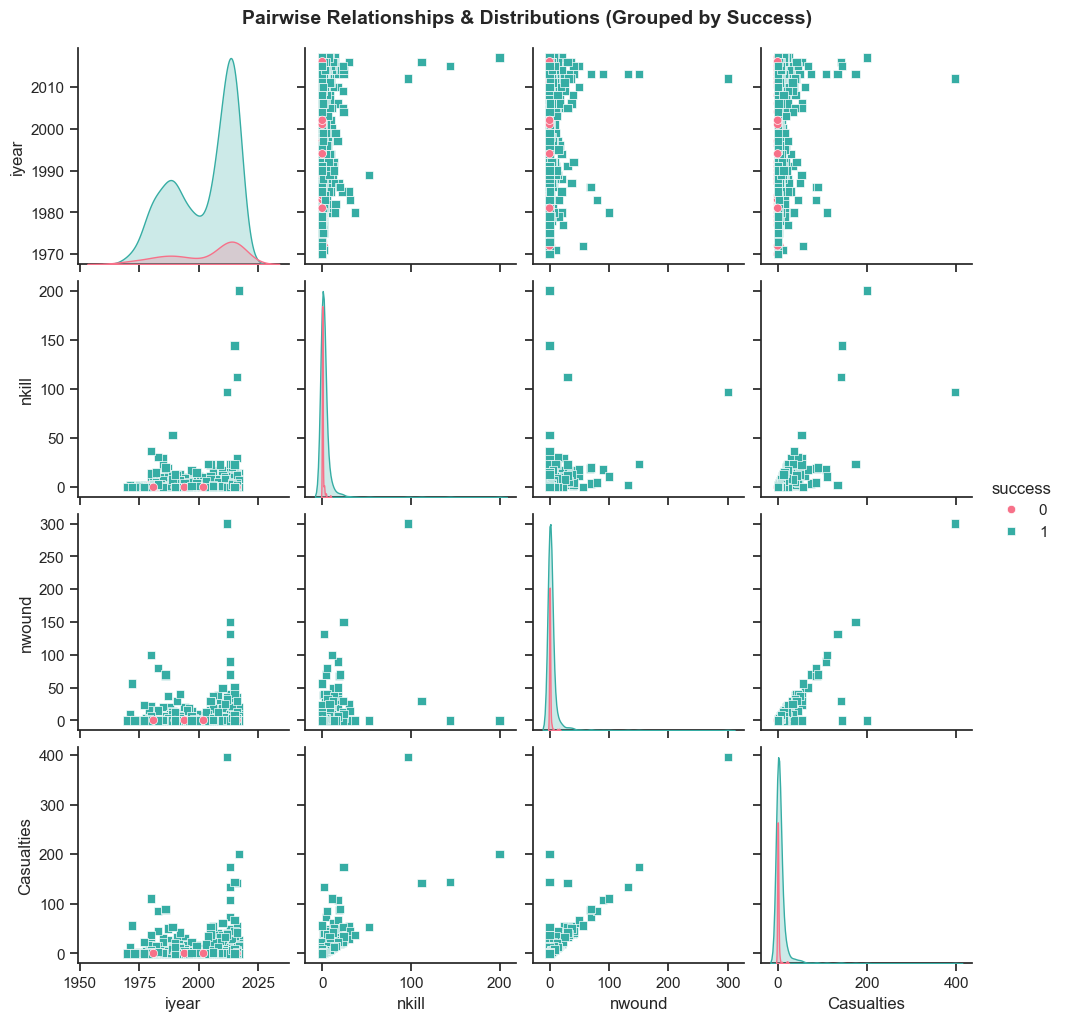

In [ ]:
# Pair Plot visualization code
# 1. Select the same numerical variables
numerical_cols = ['iyear', 'success', 'nkill', 'nwound', 'Casualties']

# 2. We use a sample of 1000 rows for better visual clarity
# We use 'success' as the hue to see the difference between failed and successful attacks
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df[numerical_cols].sample(1000),
                         hue='success',
                         palette='husl',
                         diag_kind='kde',
                         markers=["o", "s"])

pair_plot.fig.suptitle('Pairwise Relationships & Distributions (Grouped by Success)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

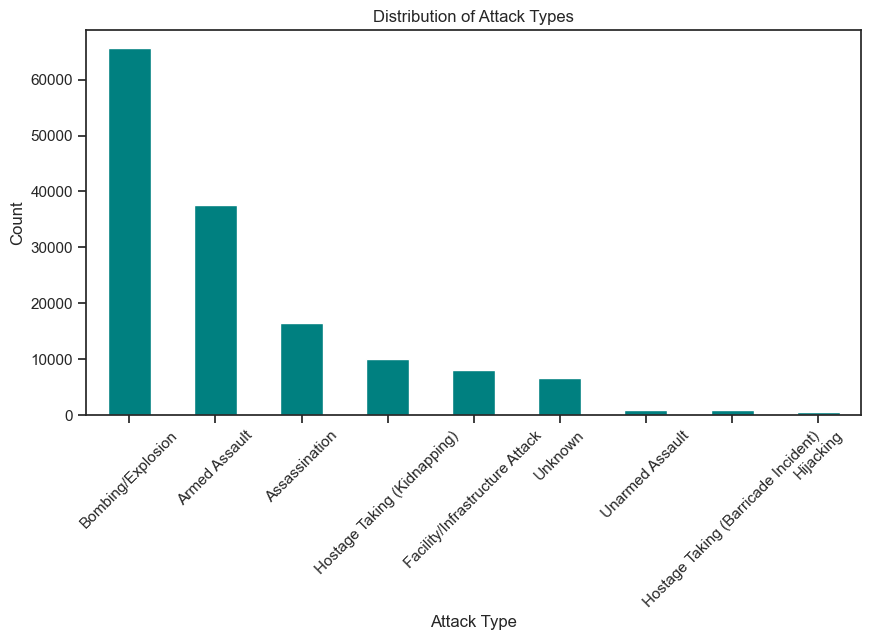

In [ ]:
plt.figure(figsize=(10,5))
df['attacktype1_txt'].value_counts().plot(kind='bar', color='teal')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

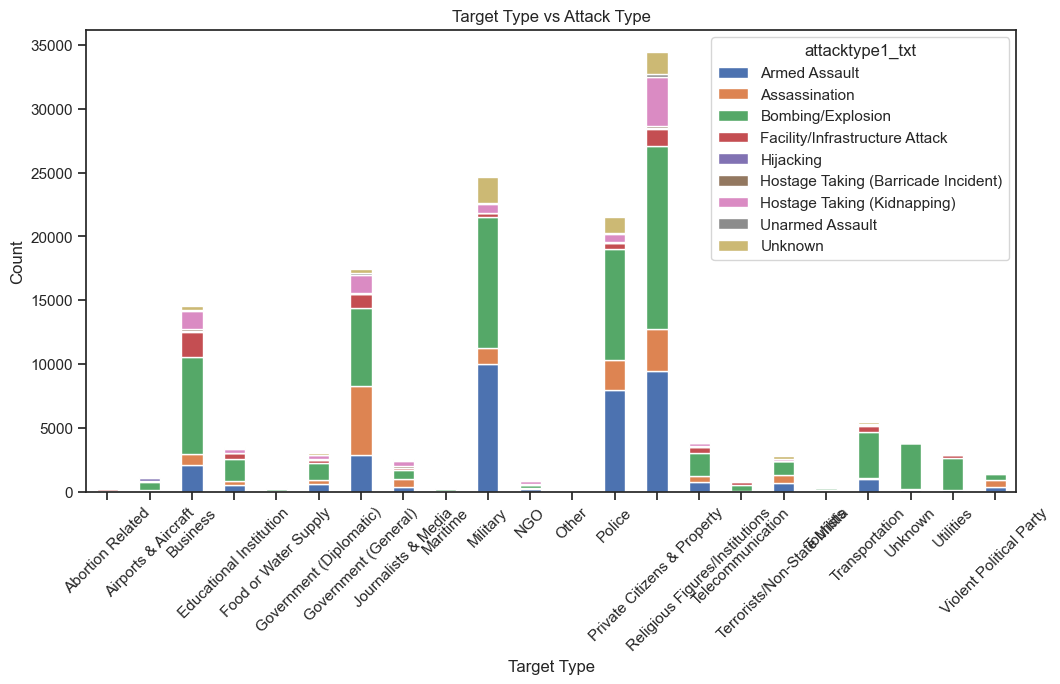

In [ ]:
ct = pd.crosstab(df['targtype1_txt'], df['attacktype1_txt'])

ct.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Target Type vs Attack Type')
plt.xlabel('Target Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

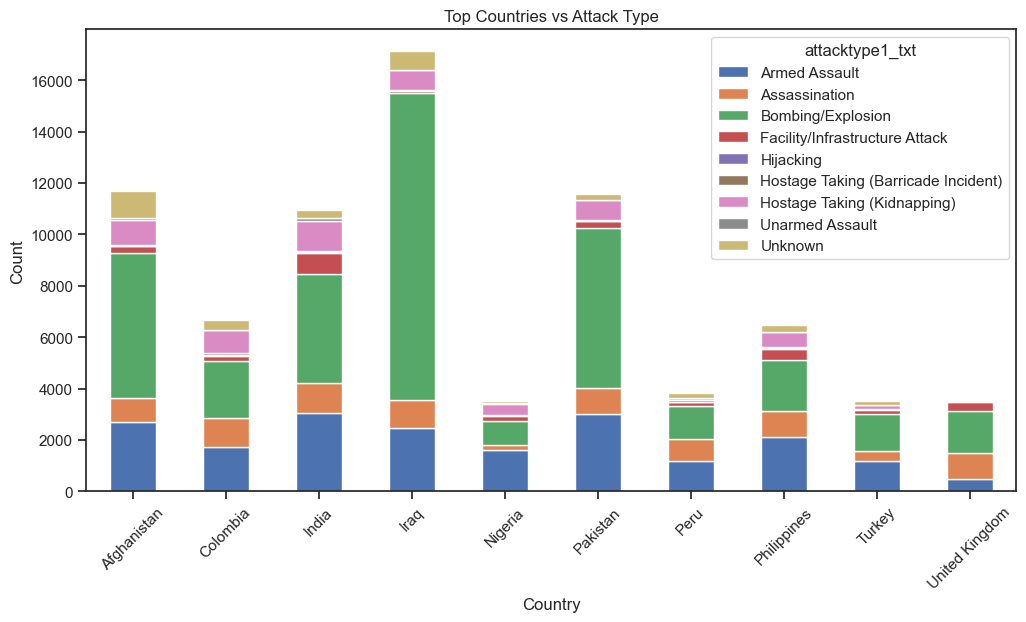

In [ ]:
top_countries = df['country_txt'].value_counts().head(10).index
df_top = df[df['country_txt'].isin(top_countries)]

ct3 = pd.crosstab(df_top['country_txt'], df_top['attacktype1_txt'])

ct3.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Top Countries vs Attack Type')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
attack_counts = df['attacktype1_txt'].value_counts(normalize=True) * 100
print(attack_counts)


attacktype1_txt
Bombing/Explosion                      44.670127
Armed Assault                          25.644012
Assassination                          11.219638
Hostage Taking (Kidnapping)             6.872642
Facility/Infrastructure Attack          5.470187
Unknown                                 4.500933
Unarmed Assault                         0.606209
Hostage Taking (Barricade Incident)     0.583732
Hijacking                               0.432520
Name: proportion, dtype: float64


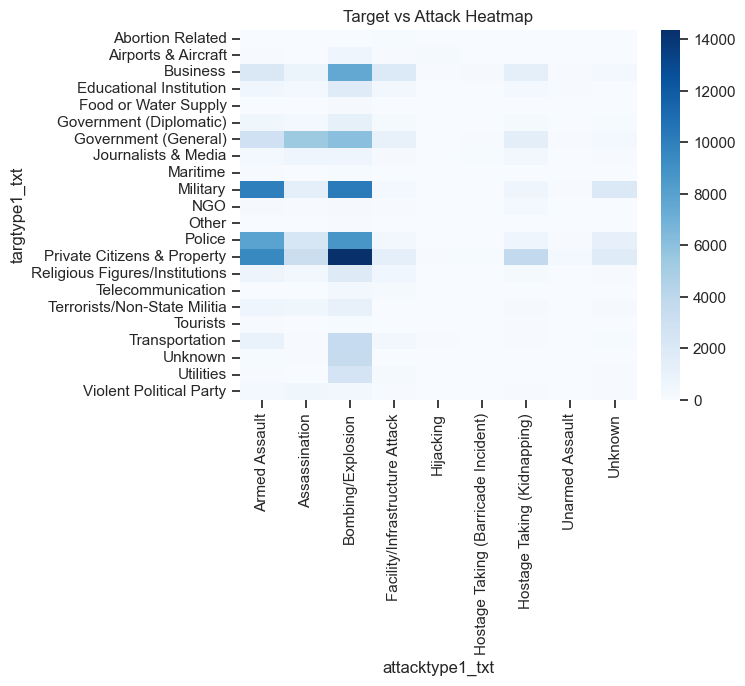

In [ ]:
ct = pd.crosstab(df['targtype1_txt'], df['attacktype1_txt'])

sns.heatmap(ct, cmap='Blues')
plt.title("Target vs Attack Heatmap")
plt.show()

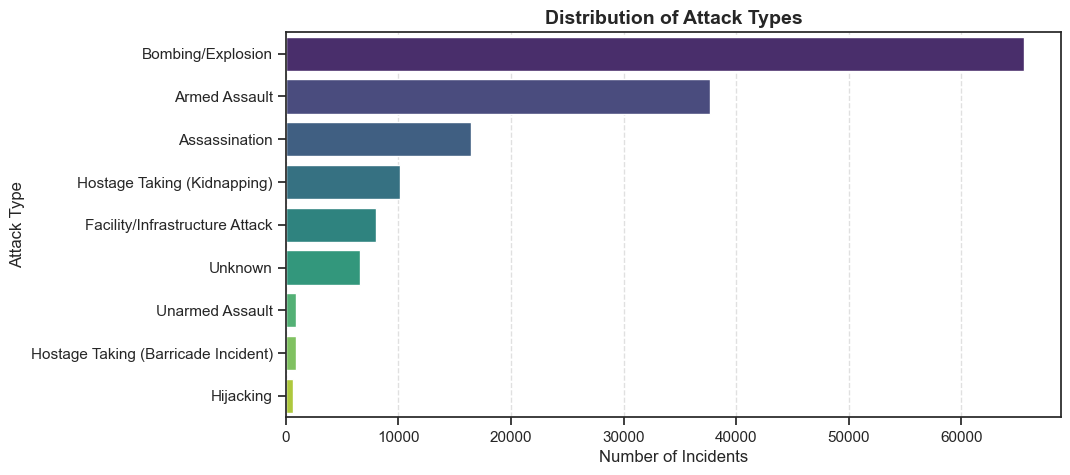

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

attack_counts = df['attacktype1_txt'].value_counts()

sns.barplot(
    x=attack_counts.values,
    y=attack_counts.index,
    palette='viridis'
)

plt.title('Distribution of Attack Types', fontsize=14, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('Attack Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

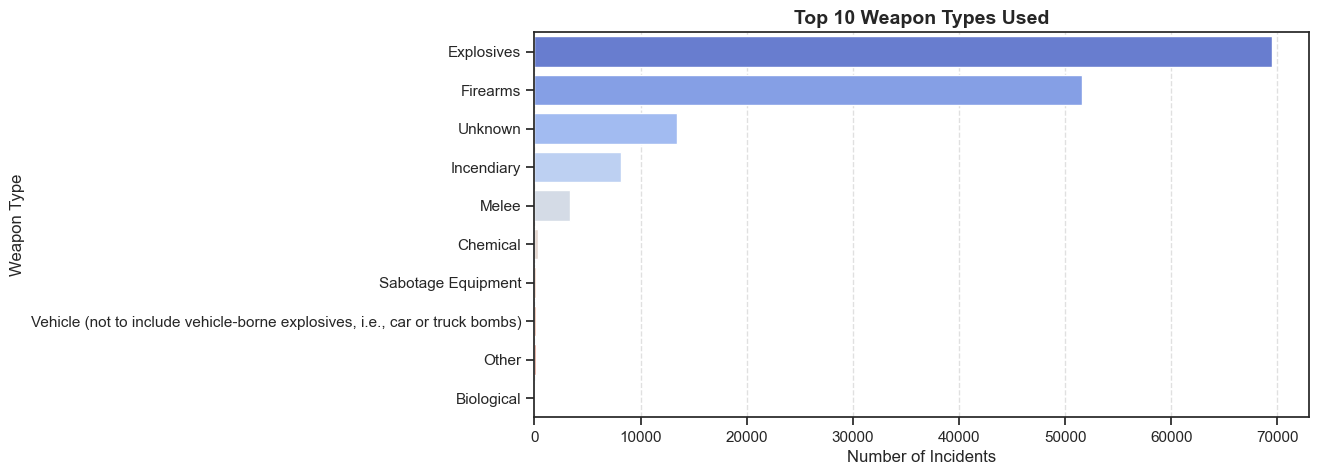

In [ ]:
plt.figure(figsize=(10,5))

weapon_counts = df['weaptype1_txt'].value_counts().head(10)

sns.barplot(
    x=weapon_counts.values,
    y=weapon_counts.index,
    palette='coolwarm'
)

plt.title('Top 10 Weapon Types Used', fontsize=14, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('Weapon Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()